In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv('Seoul_Mosquito_Final_Dataset.csv')
display(df. info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093 entries, 0 to 1092
Data columns (total 65 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tm                    1093 non-null   int64  
 1   mosquito_value_house  1093 non-null   float64
 2   mosquito_value_park   1093 non-null   float64
 3   STN                   1093 non-null   int64  
 4   WS_AVG                1093 non-null   float64
 5   WR_DAY                1093 non-null   int64  
 6   WD_MAX                1093 non-null   int64  
 7   WS_MAX                1093 non-null   float64
 8   WS_MAX_TM             1093 non-null   int64  
 9   WD_INS                1093 non-null   int64  
 10  WS_INS                1093 non-null   float64
 11  WS_INS_TM             1093 non-null   int64  
 12  TA_AVG                1093 non-null   float64
 13  TA_MAX                1093 non-null   float64
 14  TA_MAX_TM             1093 non-null   int64  
 15  TA_MIN               

None

,tm,mosquito_value_house,mosquito_value_park,STN,WS_AVG,WR_DAY,WD_MAX,WS_MAX,WS_MAX_TM,WD_INS,...,TE_15,TE_30,TE_50,날짜,수온,pH,용존산소(㎎/L),총질소(㎎/L),총인(㎎/L),총유기탄소
0,20200501,32.6,47.0,108,2.7,2328,29,5.5,1726,29,...,12.6,12.8,13.4,2020-05-01,21.298611,7.298611,6.229167,8.086181,0.116528,6.862500
1,20200502,36.6,52.7,108,2.3,1985,23,4.6,111,29,...,12.7,12.8,13.4,2020-05-02,21.418056,7.183333,5.615278,7.697153,0.201667,5.084722
2,20200503,43.0,62.0,108,2.0,1705,16,3.9,1242,14,...,12.9,12.9,13.4,2020-05-03,22.005556,7.166667,5.736111,7.444375,0.200139,5.004167
3,20200504,43.2,62.3,108,2.7,2310,27,4.6,1247,27,...,13.0,12.9,13.4,2020-05-04,23.216667,7.169444,5.648611,7.402917,0.144861,5.172348
4,20200505,46.7,67.3,108,1.9,1601,25,5.3,1354,23,...,13.2,12.9,13.4,2020-05-05,20.429167,7.102778,5.350000,7.886250,0.209861,5.837500


In [32]:
df.columns

Index(['tm', 'mosquito_value_house', 'mosquito_value_park', 'STN', 'WS_AVG',
       'WR_DAY', 'WD_MAX', 'WS_MAX', 'WS_MAX_TM', 'WD_INS', 'WS_INS',
       'WS_INS_TM', 'TA_AVG', 'TA_MAX', 'TA_MAX_TM', 'TA_MIN', 'TA_MIN_TM',
       'TD_AVG', 'TS_AVG', 'TG_MIN', 'HM_AVG', 'HM_MIN', 'HM_MIN_TM', 'PV_AVG',
       'EV_S', 'EV_L', 'FG_DUR', 'PA_AVG', 'PS_AVG', 'PS_MAX', 'PS_MAX_TM',
       'PS_MIN', 'PS_MIN_TM', 'CA_TOT', 'SS_DAY', 'SS_DUR', 'SS_CMB', 'SI_DAY',
       'SI_60M_MAX', 'SI_60M_MAX_TM', 'RN_DAY', 'RN_D99', 'RN_DUR',
       'RN_60M_MAX', 'RN_60M_MAX_TM', 'RN_10M_MAX', 'RN_10M_MAX_TM',
       'RN_POW_MAX', 'RN_POW_MAX_TM', 'SD_NEW', 'SD_NEW_TM', 'SD_MAX',
       'SD_MAX_TM', 'TE_05', 'TE_10', 'TE_15', 'TE_30', 'TE_50', '날짜', '수온',
       'pH', '용존산소(㎎/L)', '총질소(㎎/L)', '총인(㎎/L)', '총유기탄소'],
      dtype='object')

In [33]:
# 1. 제거할 피처 리스트 (노이즈 및 중복 데이터)
cols_to_drop = [
    'STN', 'TA_MAX_TM', 'TA_MIN_TM', 'WS_MAX_TM', 'WS_INS_TM', 'HM_MIN_TM', 
    'PS_MAX_TM', 'PS_MIN_TM', 'RN_60M_MAX_TM', 'RN_10M_MAX_TM', 'RN_POW_MAX_TM',
    'SD_NEW_TM', 'SD_MAX_TM', '날짜' # 'tm'과 중복
]

# 2. 이름 변경 딕셔너리
rename_dict = {
    'mosquito_value_house': 'MOS_HOUSE',
    'mosquito_value_park': 'MOS_PARK',
    '수온': 'WT_AVG',
    'pH': 'pH',
    '용존산소(㎎/L)': 'DO',
    '총질소(㎎/L)': 'TN',
    '총인(㎎/L)': 'TP',
    '총유기탄소': 'TOC',
    'TA_AVG': 'TEMP_AVG',
    'HM_AVG': 'HUMID',
    'RN_DAY': 'RAIN_DAY'
}

# 3. 적용
df_final = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df_final.rename(columns=rename_dict, inplace=True)

print(f"정리 후 남은 피처 수: {len(df_final.columns)}")
print(df_final.columns.tolist())

정리 후 남은 피처 수: 51
['tm', 'MOS_HOUSE', 'MOS_PARK', 'WS_AVG', 'WR_DAY', 'WD_MAX', 'WS_MAX', 'WD_INS', 'WS_INS', 'TEMP_AVG', 'TA_MAX', 'TA_MIN', 'TD_AVG', 'TS_AVG', 'TG_MIN', 'HUMID', 'HM_MIN', 'PV_AVG', 'EV_S', 'EV_L', 'FG_DUR', 'PA_AVG', 'PS_AVG', 'PS_MAX', 'PS_MIN', 'CA_TOT', 'SS_DAY', 'SS_DUR', 'SS_CMB', 'SI_DAY', 'SI_60M_MAX', 'SI_60M_MAX_TM', 'RAIN_DAY', 'RN_D99', 'RN_DUR', 'RN_60M_MAX', 'RN_10M_MAX', 'RN_POW_MAX', 'SD_NEW', 'SD_MAX', 'TE_05', 'TE_10', 'TE_15', 'TE_30', 'TE_50', 'WT_AVG', 'pH', 'DO', 'TN', 'TP', 'TOC']


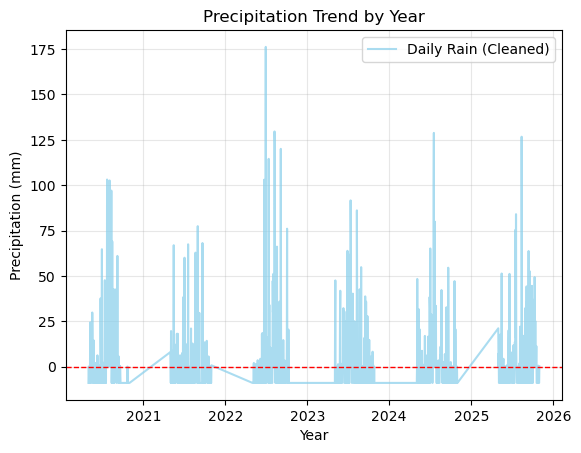

In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 'tm' 컬럼을 datetime 형식으로 변환
df_final['tm'] = pd.to_datetime(df_final['tm'].astype(str), format='%Y%m%d', errors='coerce')

# final_dataset['RN_DAY'] = final_dataset['RN_DAY'].replace(-9.0, 0.0)

plt.plot(df_final['tm'], df_final['RAIN_DAY'], color='skyblue', alpha=0.7, label='Daily Rain (Cleaned)')

# 4. x축 포맷 설정 (연도 단위)
plt.gca().xaxis.set_major_locator(mdates.YearLocator()) # 연도 단위로 눈금 표시
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # 표시 형식을 '2024' 처럼 연도만

# 0 기준선 표시
plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.title('Precipitation Trend by Year')
plt.xlabel('Year')
plt.ylabel('Precipitation (mm)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

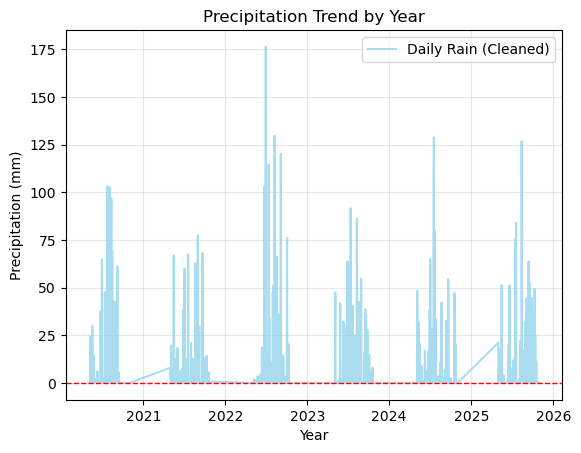

In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 'tm' 컬럼을 datetime 형식으로 변환
# final_dataset['tm'] = pd.to_datetime(final_dataset['tm'].astype(str), format='%Y%m%d', errors='coerce')

df_final['RAIN_DAY'] = df_final['RAIN_DAY'].replace(-9.0, 0.0)

plt.plot(df_final['tm'], df_final['RAIN_DAY'], color='skyblue', alpha=0.7, label='Daily Rain (Cleaned)')

# 4. x축 포맷 설정 (연도 단위)
plt.gca().xaxis.set_major_locator(mdates.YearLocator()) # 연도 단위로 눈금 표시
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # 표시 형식을 '2024' 처럼 연도만

# 0 기준선 표시
plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.title('Precipitation Trend by Year')
plt.xlabel('Year')
plt.ylabel('Precipitation (mm)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [36]:
# 1. 누적 강수량 생성 (7일, 14일)
df_final['RN_SUM_7'] = df_final['RAIN_DAY'].rolling(window=7).sum()
# final_dataset['RN_SUM_14'] = final_dataset['RN_DAY'].rolling(window=14).sum()

# 2. [추가 추천] 누적 기온 (적산온도)
# 유충이 성충이 되기까지 필요한 열에너지를 의미합니다.
# df['TA_SUM_7'] = df['TA_AVG'].rolling(window=7).sum()

# 4. 결측치 제거
# Rolling과 Shift로 인해 발생한 앞부분의 NaN 데이터를 제거합니다.
df_final = df_final.dropna().reset_index(drop=True)

print(f"피처 생성 완료! 새로운 컬럼: 'RN_SUM_7'")

피처 생성 완료! 새로운 컬럼: 'RN_SUM_7'


In [37]:
df_final['RN_SUM_7'].head()

0     0.0
1     2.3
2    26.7
3    28.0
4    31.4
Name: RN_SUM_7, dtype: float64

In [38]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1087 entries, 0 to 1086
Data columns (total 52 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   tm             1087 non-null   datetime64[ns]
 1   MOS_HOUSE      1087 non-null   float64       
 2   MOS_PARK       1087 non-null   float64       
 3   WS_AVG         1087 non-null   float64       
 4   WR_DAY         1087 non-null   int64         
 5   WD_MAX         1087 non-null   int64         
 6   WS_MAX         1087 non-null   float64       
 7   WD_INS         1087 non-null   int64         
 8   WS_INS         1087 non-null   float64       
 9   TEMP_AVG       1087 non-null   float64       
 10  TA_MAX         1087 non-null   float64       
 11  TA_MIN         1087 non-null   float64       
 12  TD_AVG         1087 non-null   float64       
 13  TS_AVG         1087 non-null   float64       
 14  TG_MIN         1087 non-null   float64       
 15  HUMID          1087 n

In [40]:
# 1. 상관계수 계산 시 수치형 데이터만 사용하도록 명시
# numeric_only=True를 넣으면 '2020-05-01' 같은 문자열을 자동으로 무시합니다.
corr_matrix = df_final.corr(numeric_only=True)

# 2. 타겟(모기 지수)과의 상관계수 확인
# 'mosquito_value' 등 실제 타겟 컬럼명으로 확인하세요.
target_corr = corr_matrix['MOS_HOUSE'].sort_values(ascending=False)

print("--- 타겟과 상관계수가 높은 피처 TOP 10 ---")
print(target_corr.head(10))

--- 타겟과 상관계수가 높은 피처 TOP 10 ---
MOS_HOUSE    1.000000
MOS_PARK     0.701544
TG_MIN       0.539079
TEMP_AVG     0.520889
TS_AVG       0.512933
TD_AVG       0.507149
WT_AVG       0.492322
PV_AVG       0.491942
TA_MAX       0.461016
SS_DUR       0.443915
Name: MOS_HOUSE, dtype: float64


In [41]:
# 1. 상관계수 계산 시 수치형 데이터만 사용하도록 명시
# numeric_only=True를 넣으면 '2020-05-01' 같은 문자열을 자동으로 무시합니다.
corr_matrix = df_final.corr(numeric_only=True)

# 2. 타겟(모기 지수)과의 상관계수 확인
# 'mosquito_value' 등 실제 타겟 컬럼명으로 확인하세요.
target_corr = corr_matrix['MOS_PARK'].sort_values(ascending=False)

print("--- 타겟과 상관계수가 높은 피처 TOP 10 ---")
print(target_corr.head(10))

--- 타겟과 상관계수가 높은 피처 TOP 10 ---
MOS_PARK     1.000000
MOS_HOUSE    0.701544
TG_MIN       0.668295
TD_AVG       0.644283
TEMP_AVG     0.629522
PV_AVG       0.628573
WT_AVG       0.588840
TS_AVG       0.568198
TA_MIN       0.545937
TA_MAX       0.538121
Name: MOS_PARK, dtype: float64


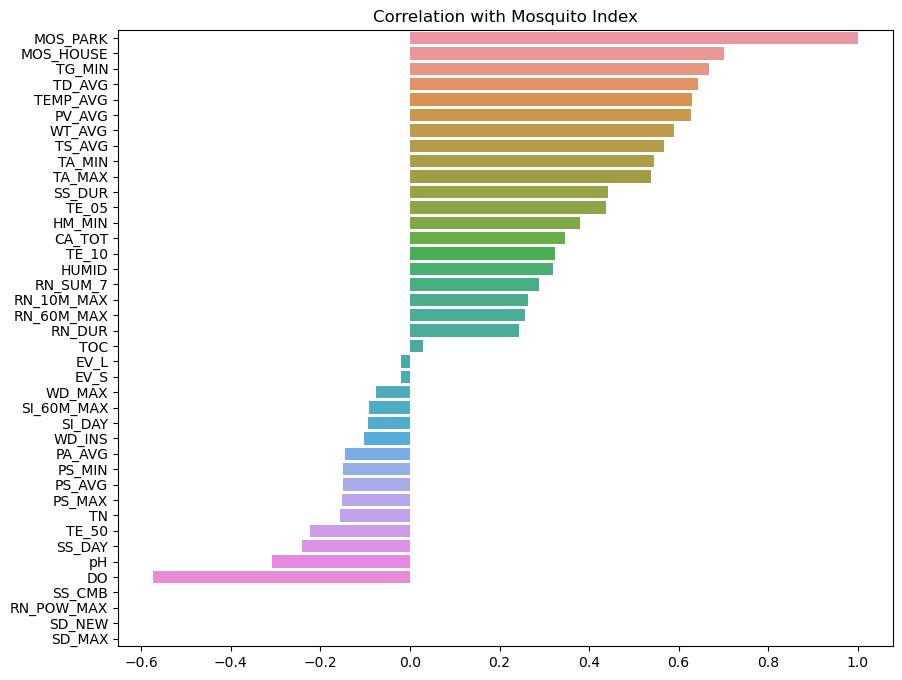

In [42]:
# 1. 상관계수 계산 (모기 지수와 다른 변수들 간)
# mosquito_index는 실제 데이터의 타겟 컬럼명으로 수정하세요.
corr_matrix = df_final.corr(numeric_only=True)
target_corr = corr_matrix['MOS_PARK'].sort_values(ascending=False)

# 2. 시각화 (상위/하위 15개)
plt.figure(figsize=(10, 8))
top_bottom_corr = pd.concat([target_corr.head(20), target_corr.tail(20)])
sns.barplot(x=top_bottom_corr.values, y=top_bottom_corr.index)
plt.title("Correlation with Mosquito Index")
plt.show()

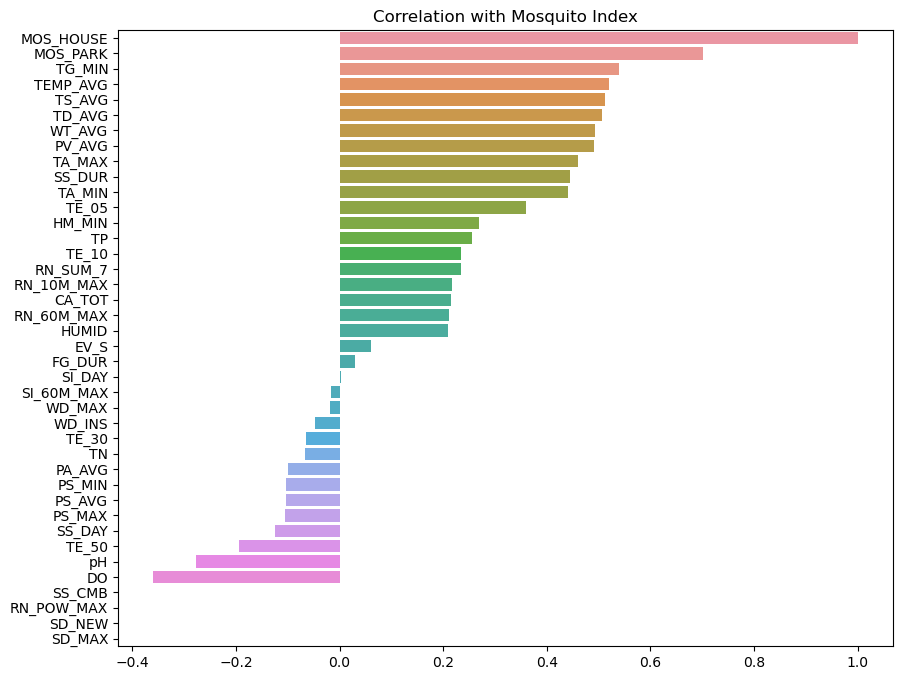

In [43]:
# 1. 상관계수 계산 (모기 지수와 다른 변수들 간)
# mosquito_index는 실제 데이터의 타겟 컬럼명으로 수정하세요.
corr_matrix = df_final.corr(numeric_only=True)
target_corr = corr_matrix['MOS_HOUSE'].sort_values(ascending=False)

# 2. 시각화 (상위/하위 15개)
plt.figure(figsize=(10, 8))
top_bottom_corr = pd.concat([target_corr.head(20), target_corr.tail(20)])
sns.barplot(x=top_bottom_corr.values, y=top_bottom_corr.index)
plt.title("Correlation with Mosquito Index")
plt.show()

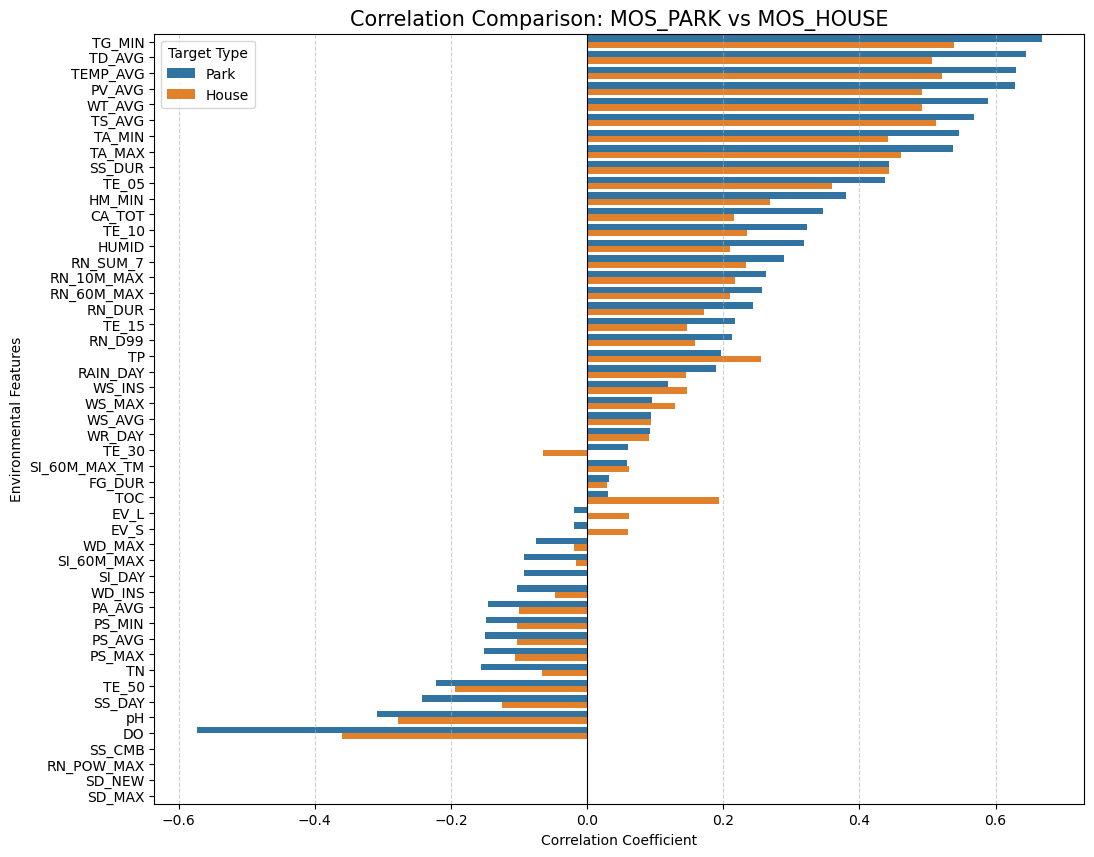

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 상관계수 계산
corr_matrix = df_final.corr(numeric_only=True)

# 2. 비교 데이터프레임 생성
# 두 타겟(HOUSE, PARK)과 다른 변수들 간의 상관계수만 추출
comp_corr = pd.DataFrame({
    'Park': corr_matrix['MOS_PARK'],
    'House': corr_matrix['MOS_HOUSE']
})

# 자기 자신(타겟 변수끼리의 상관관계)은 제외
comp_corr = comp_corr.drop(index=['MOS_PARK', 'MOS_HOUSE'], errors='ignore')

# 3. 시각화 대상 정렬 (Park 기준으로 내림차순 정렬)
comp_corr = comp_corr.sort_values(by='Park', ascending=False)

# (선택) 너무 많으면 상위/하위 일부만 추출 (예: 상위 15개)
# comp_corr = comp_corr.head(15) 

# 4. Seaborn으로 그리기 위해 데이터 재구성 (Melt)
comp_corr_melted = comp_corr.reset_index().melt(id_vars='index', var_name='Target', value_name='Correlation')

# 5. 그래프 출력
plt.figure(figsize=(12, 10))
sns.barplot(data=comp_corr_melted, x='Correlation', y='index', hue='Target', palette={'Park': '#1f77b4', 'House': '#ff7f0e'})

plt.title("Correlation Comparison: MOS_PARK vs MOS_HOUSE", fontsize=15)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Environmental Features")
plt.axvline(0, color='black', linewidth=0.8) # 0 지점에 세로선 추가
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.legend(title="Target Type")
plt.show()

✅ 최종 학습 데이터 준비 완료!
입력 피처: ['TEMP_AVG', 'HUMID', 'WT_AVG', 'DO', 'RN_SUM_7', 'TG_MIN']
출력 타겟: ['MOS_PARK']
데이터 크기: (1087, 8)


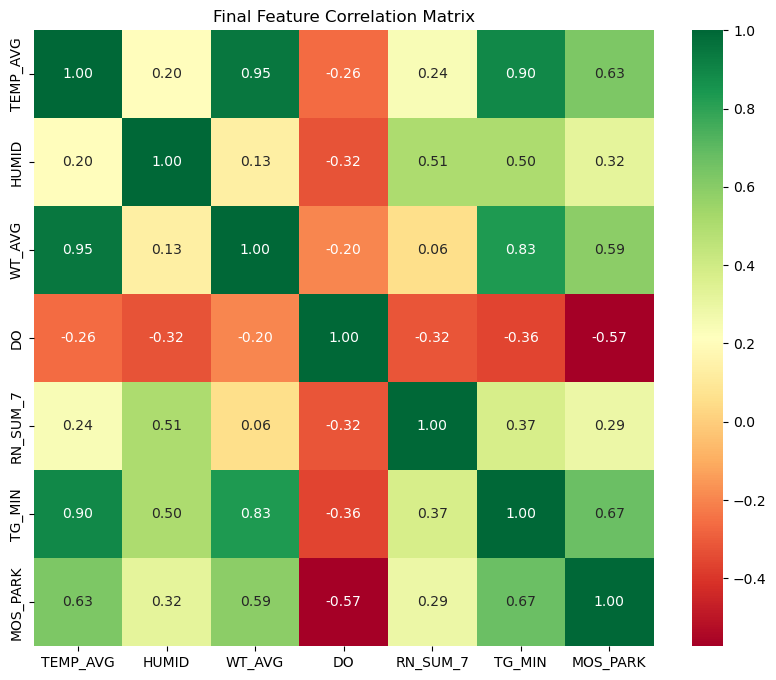

In [46]:
# 1. 최종 피처 및 타겟 설정
select_features = ['TEMP_AVG', 'HUMID', 'WT_AVG', 'DO', 'RN_SUM_7', 'TG_MIN']
target = ['MOS_PARK']
time_col = ['tm']

# 2. 최종 데이터프레임 생성
# (RAIN_SUM_7 피처가 생성되어 있는지 확인 후 실행하세요)
final_cols = time_col + select_features + target
df_train_final = df_final[final_cols].copy()

# 3. 결측치 최종 확인 및 제거
# Rolling 과정에서 생긴 초기 6일간의 NaN 데이터 등을 제거합니다.
df_train_final = df_train_final.dropna().reset_index(drop=True)

print(f"✅ 최종 학습 데이터 준비 완료!")
print(f"입력 피처: {select_features}")
print(f"출력 타겟: {target}")
print(f"데이터 크기: {df_train_final.shape}")

# 4. 상관계수 히트맵 (PPT용 최종본)
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(df_train_final.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Final Feature Correlation Matrix")
plt.show()

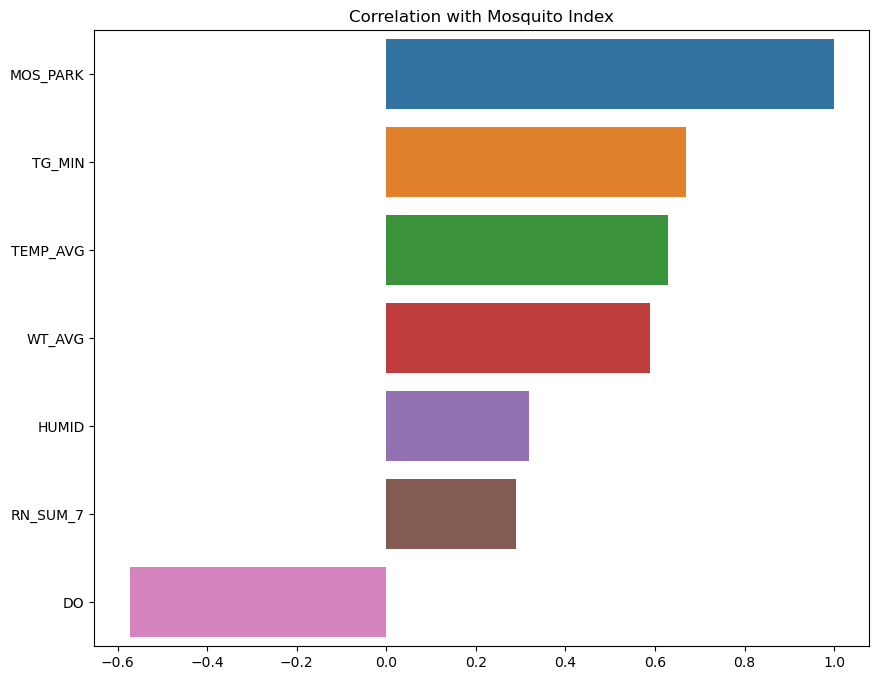

In [48]:
# 1. 상관계수 계산 (모기 지수와 다른 변수들 간)
# mosquito_index는 실제 데이터의 타겟 컬럼명으로 수정하세요.
corr_matrix = df_train_final.corr(numeric_only=True)
target_corr = corr_matrix['MOS_PARK'].sort_values(ascending=False)

# 2. 시각화 (상위/하위 15개)
plt.figure(figsize=(10, 8))
top_bottom_corr = pd.concat([target_corr.head(20), target_corr.tail(20)])
sns.barplot(x=top_bottom_corr.values, y=top_bottom_corr.index)
plt.title("Correlation with Mosquito Index")
plt.show()

In [47]:
import pandas as pd

# 1. 최종 저장할 컬럼 리스트 정의
# 'tm'과 선택한 6개 피처, 그리고 타겟인 'MOS_PARK' 포함
save_features = ['tm', 'TEMP_AVG', 'HUMID', 'WT_AVG', 'DO', 'RN_SUM_7', 'TG_MIN', 'MOS_PARK']

# 2. 필요한 컬럼만 추출하여 새로운 데이터프레임 생성
# df는 현재 작업 중인 데이터프레임 변수명에 맞게 수정하세요.
df_save = df_final[save_features].copy()

# 3. 결측치 최종 제거
# Rolling(누적값) 계산 등으로 인해 발생한 초기 행의 NaN 등을 제거합니다.
initial_count = len(df_save)
df_save = df_save.dropna().reset_index(drop=True)
dropped_count = initial_count - len(df_save)

print(f"결측치 제거 완료: {dropped_count}개의 행이 삭제되었습니다.")
print(f"최종 저장 데이터 크기: {df_save.shape}")

# 4. 파일 저장 (CSV 형식)
# index=False를 설정해야 불필요한 인덱스 번호가 저장되지 않습니다.
file_name = 'mosquito_park_final_data.csv'
df_save.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"✅ 파일이 성공적으로 저장되었습니다: {file_name}")

# 5. 저장된 데이터 상단 확인
print(df_save.head())

결측치 제거 완료: 0개의 행이 삭제되었습니다.
최종 저장 데이터 크기: (1087, 8)
✅ 파일이 성공적으로 저장되었습니다: mosquito_park_final_data.csv
          tm  TEMP_AVG  HUMID     WT_AVG        DO  RN_SUM_7  TG_MIN  MOS_PARK
0 2020-05-07      20.7   32.5  21.770541  6.286111       0.0    11.6      21.6
1 2020-05-08      19.9   32.8  21.755556  6.190278       2.3    11.7      59.4
2 2020-05-09      14.2   94.4  19.347222  4.212500      26.7    11.9      63.6
3 2020-05-10      14.4   88.6  18.548611  4.976389      28.0    12.2      61.0
4 2020-05-11      16.5   61.0  19.930177  5.525253      31.4     9.8      45.3


아래는 폐기

In [44]:
# 상관계수의 절대값이 0.2 이상인 피처들만 선택
# (0.2 미만은 모기 활동과 연관성이 너무 적다고 판단)
selected_features = target_corr[target_corr.abs() >= 0.2].index.tolist()

# 타겟 데이터(mosquito_value)는 당연히 포함되므로 확인
print("선택된 주요 피처 리스트:")
print(selected_features)

# 최종 학습용 데이터프레임 생성
final_training_df = df_final[selected_features]

선택된 주요 피처 리스트:
['MOS_HOUSE', 'MOS_PARK', 'TG_MIN', 'TEMP_AVG', 'TS_AVG', 'TD_AVG', 'WT_AVG', 'PV_AVG', 'TA_MAX', 'SS_DUR', 'TA_MIN', 'TE_05', 'HM_MIN', 'TP', 'TE_10', 'RN_SUM_7', 'RN_10M_MAX', 'CA_TOT', 'RN_60M_MAX', 'HUMID', 'pH', 'DO']


In [ ]:
import numpy as np

# 1. 수치형 데이터만 추출
df_numeric = df_final.select_dtypes(include=[np.number])

# 2. 변수 간 상관계수 계산
corr_matrix = df_numeric.corr().abs()

# 3. 상삼각행렬(Upper triangle)만 선택 (중복 제거용)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. 상관계수가 0.9 이상인 컬럼 찾기
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

# 5. 해당 컬럼 삭제
final_dataset_slim = df.drop(columns=to_drop)

print(f"삭제된 중복 변수 개수: {len(to_drop)}개")
print(f"남은 변수 리스트: {final_dataset_slim.columns.tolist()}")

삭제된 중복 변수 개수: 17개
남은 변수 리스트: ['tm', 'mosquito_value_house', 'mosquito_value_park', 'STN', 'WS_AVG', 'WD_MAX', 'WS_MAX', 'WS_MAX_TM', 'WD_INS', 'WS_INS_TM', 'TA_AVG', 'TA_MAX_TM', 'TA_MIN', 'TA_MIN_TM', 'TD_AVG', 'HM_AVG', 'HM_MIN_TM', 'EV_S', 'FG_DUR', 'PA_AVG', 'PS_MAX_TM', 'PS_MIN_TM', 'CA_TOT', 'SS_DAY', 'SS_DUR', 'SS_CMB', 'SI_60M_MAX', 'SI_60M_MAX_TM', 'RN_DAY', 'RN_D99', 'RN_DUR', 'RN_60M_MAX', 'RN_60M_MAX_TM', 'RN_10M_MAX_TM', 'RN_POW_MAX', 'RN_POW_MAX_TM', 'SD_NEW', 'SD_NEW_TM', 'SD_MAX', 'SD_MAX_TM', 'TE_05', 'TE_30', '날짜', 'pH', '용존산소(㎎/L)', '총질소(㎎/L)', '총인(㎎/L)', '총유기탄소']
